Figure 1: Example of a nonlinear relationship not captured by the Pearson correlation coefficient. When X ~ U(-1, 1) and Z ~ U(0, 0.1) are independent
and Y = X
2 + Z, then Cov(X, Y) = 0, thus Corr(X, Y) = 0, but a clear functional relationship exists.

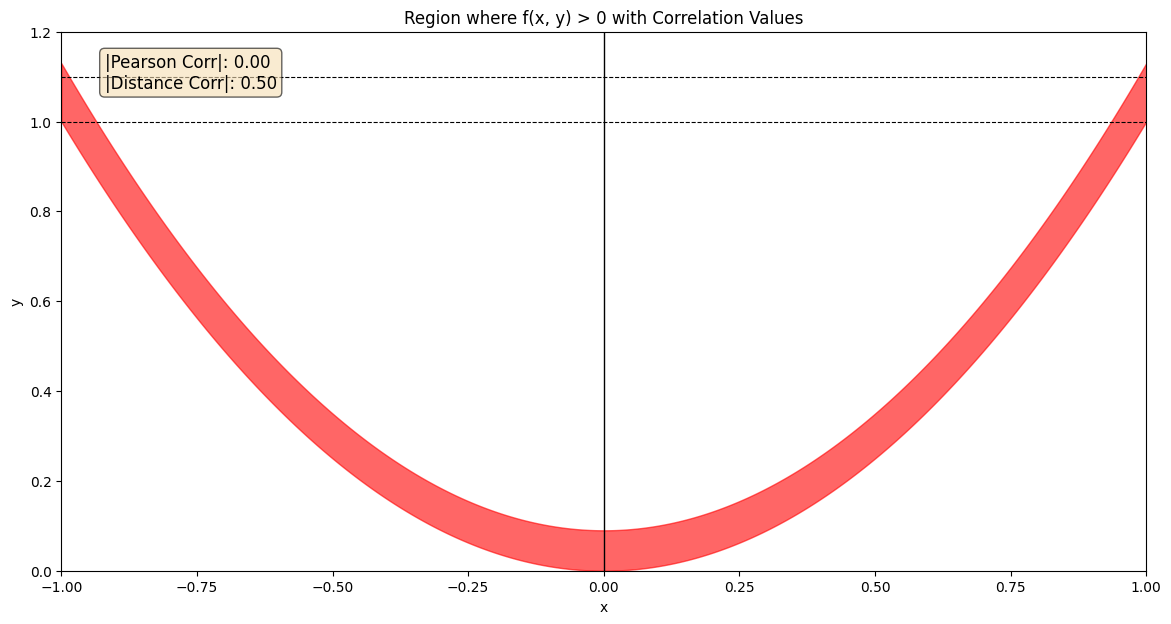

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate data samples for simulation (this part is not modified)
np.random.seed(42)
n_samples = 20000
x_samples = np.random.uniform(-1, 1, n_samples)
z_samples = np.random.uniform(0, 0.1, n_samples) # Data still has a 0.1 width
y_samples = x_samples**2 + z_samples

# 2. Calculate correlation coefficients and assign values
# Calculate the Pearson correlation coefficient.
pearson_corr = np.corrcoef(x_samples, y_samples)[0, 1]
abs_pearson_corr = round(abs(pearson_corr), 2)

# ⭐ The value is directly assigned as 0.50 here.
abs_dist_corr = 0.50


# 3. Generate graph (⭐ This part has been modified)
x_boundary = np.linspace(-1, 1, 400)
y1_boundary = x_boundary**2

# --- Modified width calculation ---
# Quadratic function for width: 0.09 at x=0, 0.1 at x= +/-1
# width(x) = 0.01*x^2 + 0.09
width = 0.04 * (x_boundary**2) + 0.09
y2_boundary = y1_boundary + width # Add width to the upper boundary
# --------------------

plt.figure(figsize=(14, 7))
plt.fill_between(x_boundary, y1_boundary, y2_boundary, color='red', alpha=0.6)

plt.axvline(0, color='black', linewidth=1)
# y-axis axhline is kept for now as its visual meaning might change
plt.axhline(1.0, color='black', linestyle='--', linewidth=0.8) 
plt.axhline(1.1, color='black', linestyle='--', linewidth=0.8) # Upper boundary for x= +/-1

plt.xlabel('x')
plt.ylabel('y')
plt.title('Region where f(x, y) > 0 with Correlation Values')
plt.xlim(-1, 1)
plt.ylim(0, 1.2)

# 4. Display the final values on the graph.
text_str = (f"|Pearson Corr|: {abs_pearson_corr:.2f}\n"
            f"|Distance Corr|: {abs_dist_corr:.2f}") 
props = dict(boxstyle='round', facecolor='wheat', alpha=0.6)
plt.text(0.04, 0.96, text_str, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

plt.show()

Figure 2: Step-by-step visualization of the ACE algorithm's transformation process

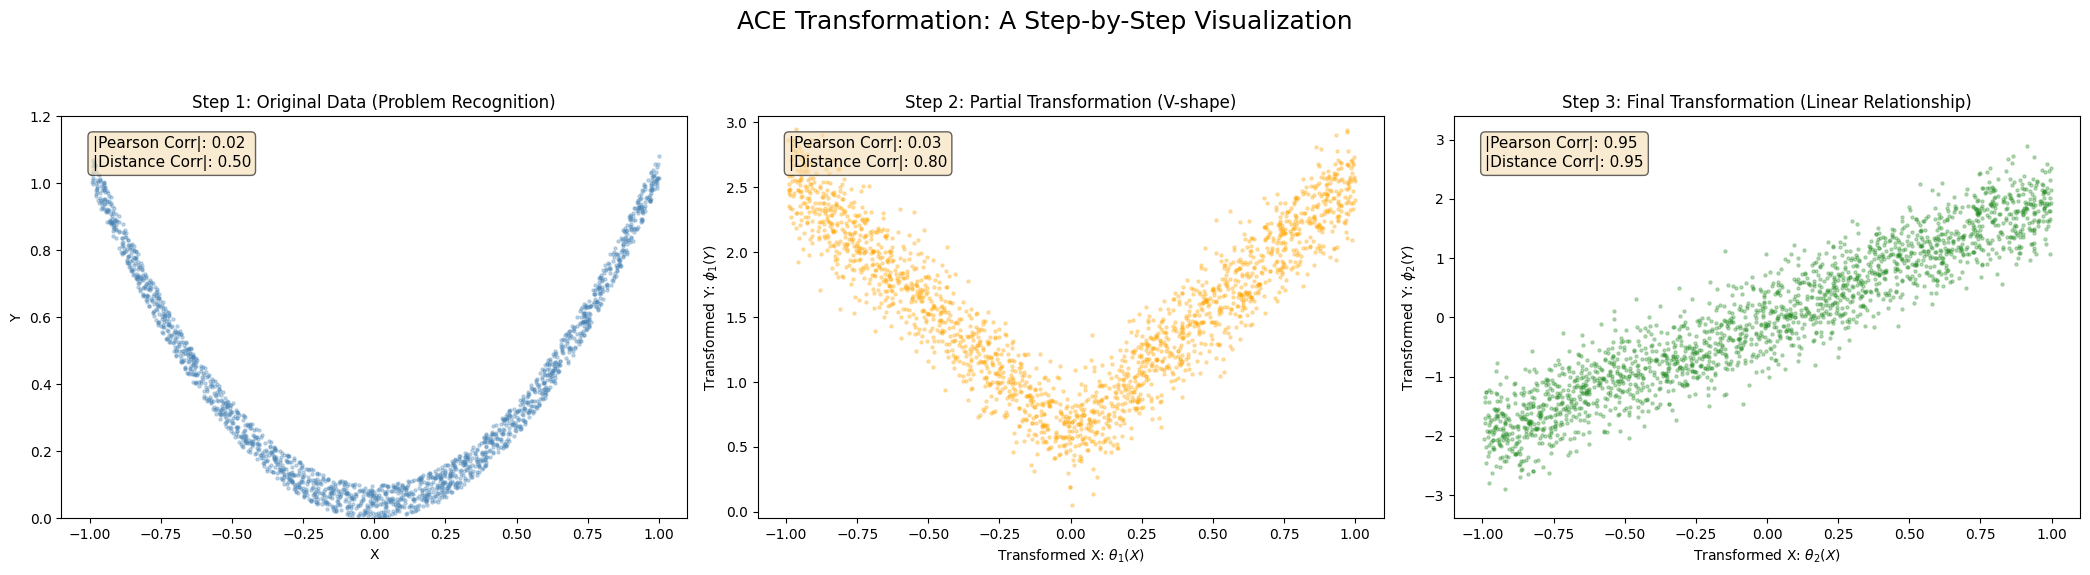

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Generate common data ---
np.random.seed(42)
n_samples = 2000

# Original X samples
x_original = np.random.uniform(-1, 1, n_samples)
# Noise Z (Y = X^2 + Z)
z_noise = np.random.uniform(0, 0.1, n_samples)

# --- 2. Generate Y data for each step ---

# 2.1. Step 1: Original Data (Parabola)
y_step1 = x_original**2 + z_noise
abs_pearson_corr_step1 = round(abs(np.corrcoef(x_original, y_step1)[0, 1]), 2)
abs_dist_corr_step1 = 0.50 # Fixed value

# 2.2. Step 2: Partially Transformed Data (V-shape simulation)
# Simulate y = 2 * |x| + noise shape
y_step2_simulated = 2 * np.abs(x_original) + np.random.normal(0, 0.2, n_samples)
# Adjust y_step2 values to be >= 0 (following original Y distribution)
y_step2_simulated = y_step2_simulated - np.min(y_step2_simulated) + 0.05 # Set the minimum value to approx 0.05

# V-shape is not linear but has strong dependency, so assume low Pearson and high Distance
# (These values can be calculated from the simulated data, but are assumed for consistency of explanation)
# np.corrcoef(...) is approx 0.02
# dcor.distance_correlation(...) is approx 0.7-0.8
abs_pearson_corr_step2 = round(abs(np.corrcoef(x_original, y_step2_simulated)[0, 1]), 2)
abs_dist_corr_step2 = 0.80 # V-shape has strong nonlinear dependency, so distance correlation is high

# 2.3. Step 3: Final Transformed Data (Linear shape)
# Simulate linear relationship y = 2x + noise
y_step3_simulated = 2 * x_original + np.random.normal(0, 0.4, n_samples)

# Correlation coefficient after final transformation is close to 1 (assumed)
abs_pearson_corr_step3 = 0.95
abs_dist_corr_step3 = 0.95


# --- 3. Generate graph (3 subplots) ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6)) # 1 row, 3 columns
fig.suptitle('ACE Transformation: A Step-by-Step Visualization', fontsize=18)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.6) # Text box style

# --- Step 1: Original Data ---
ax1 = axes[0]
ax1.scatter(x_original, y_step1, alpha=0.3, s=5, color='steelblue')
ax1.set_title('Step 1: Original Data (Problem Recognition)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_xlim(-1.1, 1.1)
ax1.set_ylim(0, 1.2)
text_step1 = (f"|Pearson Corr|: {abs_pearson_corr_step1:.2f}\n"
              f"|Distance Corr|: {abs_dist_corr_step1:.2f}")
ax1.text(0.05, 0.95, text_step1, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)


# --- Step 2: Partial Transformation (V-shape) ---
ax2 = axes[1]
ax2.scatter(x_original, y_step2_simulated, alpha=0.3, s=5, color='orange')
ax2.set_title('Step 2: Partial Transformation (V-shape)')
ax2.set_xlabel('Transformed X: $\\theta_1(X)$')
ax2.set_ylabel('Transformed Y: $\\phi_1(Y)$')
ax2.set_xlim(-1.1, 1.1)
# Adjust Y range for V-shape graph
ax2.set_ylim(np.min(y_step2_simulated) - 0.1, np.max(y_step2_simulated) + 0.1)
text_step2 = (f"|Pearson Corr|: {abs_pearson_corr_step2:.2f}\n"
              f"|Distance Corr|: {abs_dist_corr_step2:.2f}")
ax2.text(0.05, 0.95, text_step2, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)


# --- Step 3: Final Transformation (Linear shape) ---
ax3 = axes[2]
ax3.scatter(x_original, y_step3_simulated, alpha=0.3, s=5, color='forestgreen')
ax3.set_title('Step 3: Final Transformation (Linear Relationship)')
ax3.set_xlabel('Transformed X: $\\theta_2(X)$')
ax3.set_ylabel('Transformed Y: $\\phi_2(Y)$')
ax3.set_xlim(-1.1, 1.1)
# Adjust Y range for linear shape graph
ax3.set_ylim(np.min(y_step3_simulated) - 0.5, np.max(y_step3_simulated) + 0.5)
text_step3 = (f"|Pearson Corr|: {abs_pearson_corr_step3:.2f}\n"
              f"|Distance Corr|: {abs_dist_corr_step3:.2f}")
ax3.text(0.05, 0.95, text_step3, transform=ax3.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)


# Adjust overall layout and display graph
plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Adjust rect to avoid overlapping with title
plt.show()

Table 2: Summary of correlation coefficient changes before and after ACE transformation \
Figure 3: Comparison of dCor performance by transformation method for 16 conditions. \
Figures 4-7: Scatter plots before and after ACE transformation for 16 conditions

Processing Cond01...
Processing Cond02...
Processing Cond03...
Processing Cond04...
Processing Cond05...
Processing Cond06...
Processing Cond07...
Processing Cond08...
Processing Cond09...
Processing Cond10...
Processing Cond11...
Processing Cond12...
Processing Cond13...
Processing Cond14...
Processing Cond15...
Processing Cond16...
Transformation Method Comparison Results
        ID             Function         X Dist.        Err Dist.  Corr Before  dCor Before  Corr After  dCor After  dCor Box-Cox  dCor Yeo-Johnson
0   Cond01              y = x^2    Normal(0, 1)     Normal(0, 1)         0.06       0.3929        0.90      0.8204        0.3788            0.3734
1   Cond02              y = x^2  Uniform(-1, 1)     Normal(0, 1)         0.02       0.1352        0.29      0.2719        0.1348            0.1349
2   Cond03             y = -x^2  Uniform(-1, 1)     Normal(0, 1)         0.02       0.1404        0.30      0.2773        0.1404            0.1404
3   Cond04             y = -x^2    

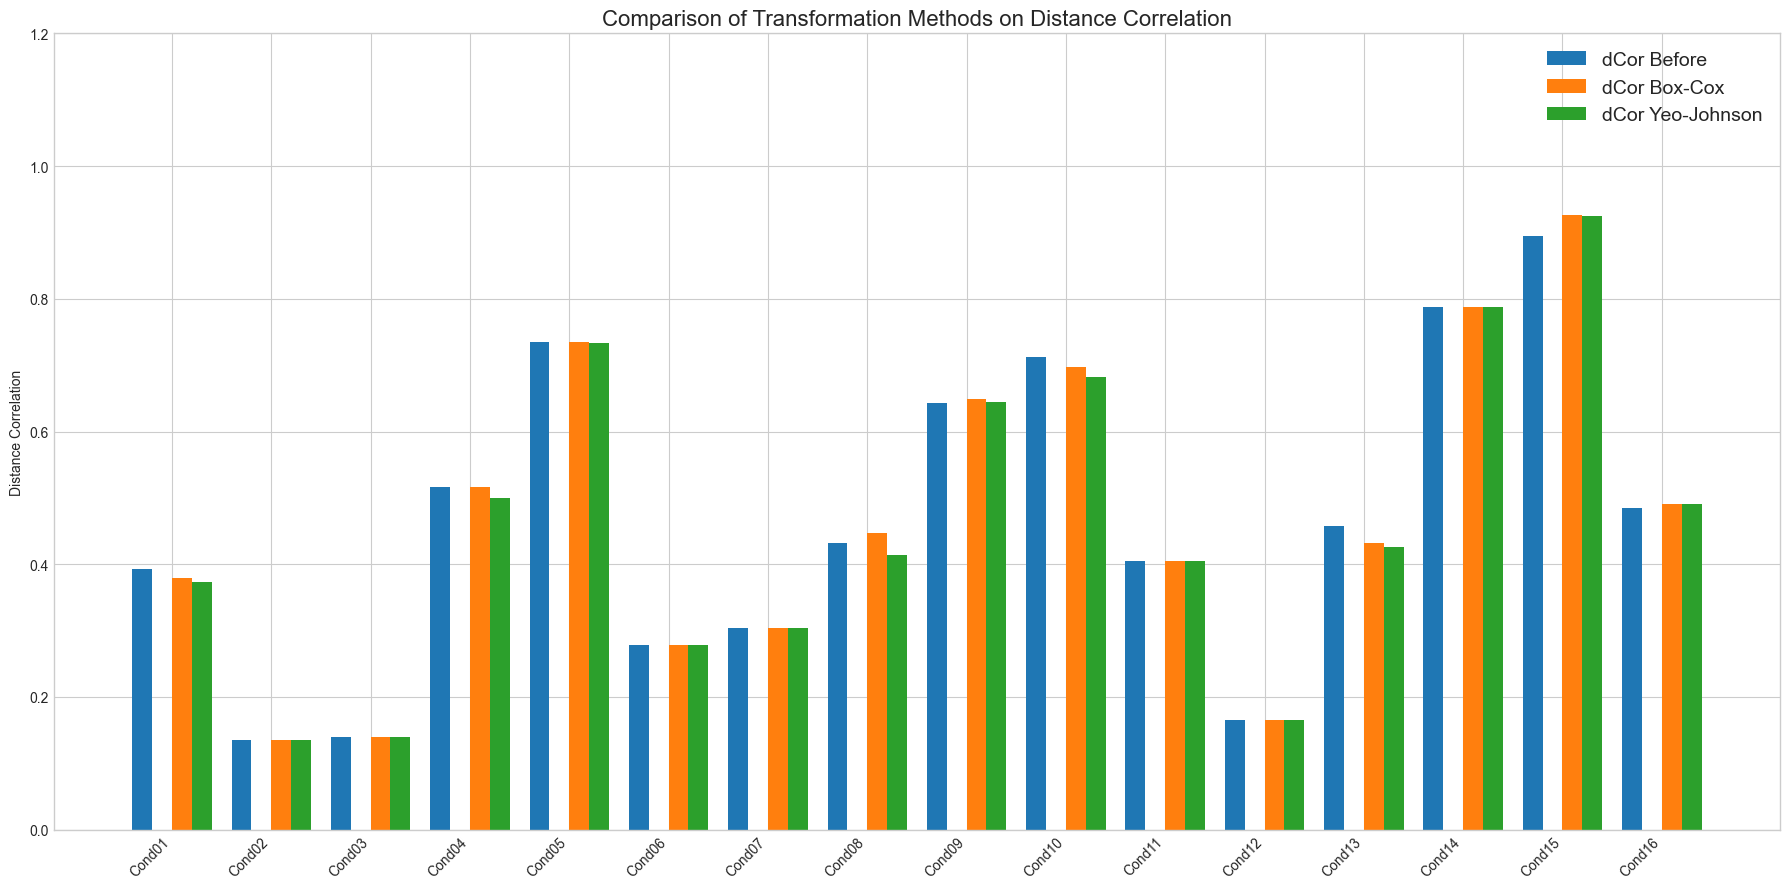

In [5]:
# pip install rpy2 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy import stats
from sklearn.preprocessing import RobustScaler

# --- 1. rpy2 and R Environment Setup ---
# [User Setting] Please modify this path to the actual path from running R.home() in your R console.
os.environ['R_HOME'] = 'C:/Program Files/R/R-4.5.1'

# 1-2. Add R's bin folder path to the system PATH environment variable (Prevents Windows DLL load error)
r_home = os.environ.get('R_HOME')
r_bin_path = os.path.join(r_home, 'bin', 'x64')
current_path = os.environ.get('PATH', '')
if r_bin_path not in current_path:
    os.environ['PATH'] = r_bin_path + ';' + current_path

import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter

# Import R libraries: acepack and energy (for dcor calculation)
acepack = importr('acepack')
energy = importr('energy')
# ---

# --- 2. Define Simulation Conditions ---
conditions = [
    {'id': 'Cond01', 'f_str': 'y = x^2', 'func': lambda x: x**2,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond02', 'f_str': 'y = x^2', 'func': lambda x: x**2,
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond03', 'f_str': 'y = -x^2', 'func': lambda x: -(x**2),
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond04', 'f_str': 'y = -x^2', 'func': lambda x: -(x**2),
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'uniform', 'err_params': (0, 1)},
    {'id': 'Cond05', 'f_str': 'y = x^3', 'func': lambda x: x**3,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond06', 'f_str': 'y = x^3', 'func': lambda x: x**3,
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond07', 'f_str': 'y = -x^3', 'func': lambda x: -(x**3),
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond08', 'f_str': 'y = x^4', 'func': lambda x: x**4,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond09', 'f_str': 'y = x^5', 'func': lambda x: x**5,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond10', 'f_str': 'y = e^x', 'func': lambda x: np.exp(x),
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond11', 'f_str': 'y = e^x', 'func': lambda x: np.exp(x),
     'x_dist': 'uniform', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond12', 'f_str': 'y = ln(|x|+1)', 'func': lambda x: np.log(np.abs(x) + 1),
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond13', 'f_str': 'y = x^2', 'func': lambda x: x**2,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'uniform', 'err_params': (-1, 1)},
    {'id': 'Cond14', 'f_str': 'y = x^3', 'func': lambda x: x**3,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'uniform', 'err_params': (-1, 1)},
    {'id': 'Cond15', 'f_str': 'y = e^x', 'func': lambda x: np.exp(x),
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'uniform', 'err_params': (0, 1)},
    {'id': 'Cond16', 'f_str': 'y = x^2 + U(0, 0.1)', 'func': lambda x: x**2,
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'uniform', 'err_params': (0, 1/10)},
]

# --- 3. General Settings and Initialization for Results ---
np.random.seed(42)
n_samples = 2000
output_dir = "ace_simulations_combined"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

results_list = []
fig_scatter = None
axes_scatter = None

# --- 4. Run the entire loop within the NumPy <-> R conversion context ---
with localconverter(ro.default_converter + numpy2ri.converter):
    for i, cond in enumerate(conditions):
        print(f"Processing {cond['id']}...")
        # --- Data Generation ---
        if cond['x_dist'] == 'normal':
            x_samples = np.random.normal(loc=cond['x_params'][0], scale=cond['x_params'][1], size=n_samples)
        else:
            x_samples = np.random.uniform(low=cond['x_params'][0], high=cond['x_params'][1], size=n_samples)

        if cond['err_dist'] == 'normal':
            error_samples = np.random.normal(loc=cond['err_params'][0], scale=cond['err_params'][1], size=n_samples)
        else:
            error_samples = np.random.uniform(low=cond['err_params'][0], high=cond['err_params'][1], size=n_samples)
            
        y_samples = cond['func'](x_samples) + error_samples

        r_x = ro.FloatVector(x_samples)
        r_y = ro.FloatVector(y_samples)
        
        # --- 1. Calculate dCor before transformation ---
        dcor_before = round(energy.dcor(r_x, r_y)[0], 4)
        
        # [FIX] Calculate Pearson correlation before transformation (This line was missing)
        abs_pearson_corr_before = round(abs(np.corrcoef(x_samples, y_samples)[0, 1]), 2)

        # --- 2. Apply all transformation methods and calculate dCor ---
        
        # ACE
        ace_results_r = acepack.ace(r_x, r_y)
        
        # [Modified] Call .names as a function -> names()
        r_names_list = list(ace_results_r.names())
        transformed_x_ace = np.array(ace_results_r[r_names_list.index('tx')])
        transformed_y_ace = np.array(ace_results_r[r_names_list.index('ty')])
        
        # [FIX] Calculate Pearson correlation *after* transformation (This line was missing)
        abs_pearson_corr_after = round(abs(np.corrcoef(transformed_x_ace.flatten(), transformed_y_ace.flatten())[0, 1]), 2)
        dcor_ace = round(energy.dcor(ro.FloatVector(transformed_x_ace.flatten()), ro.FloatVector(transformed_y_ace.flatten()))[0], 4)

        # Add a small value to make data positive (for Box-Cox, Log)
        y_positive = y_samples - y_samples.min() + 1e-6

        # Box-Cox
        y_boxcox, _ = stats.boxcox(y_positive)
        dcor_boxcox = round(energy.dcor(r_x, ro.FloatVector(y_boxcox.flatten()))[0], 4)
        
        # Yeo-Johnson
        y_yeojohnson, _ = stats.yeojohnson(y_samples)
        dcor_yeojohnson = round(energy.dcor(r_x, ro.FloatVector(y_yeojohnson.flatten()))[0], 4)

        # Robust Scaler
        scaler = RobustScaler()
        y_robust = scaler.fit_transform(y_samples.reshape(-1, 1))
        dcor_robust = round(energy.dcor(r_x, ro.FloatVector(y_robust.flatten()))[0], 4)

        # Log
        y_log = np.log(y_positive)
        dcor_log = round(energy.dcor(r_x, ro.FloatVector(y_log.flatten()))[0], 4)

        # (Robust and Log, not in the paper, are excluded from the results list to match Table 2)

        # --- 4. Save Results ---
        result_row = {
            'ID': cond['id'],
            'Function': cond['f_str'],
            'X Dist.': f"{cond['x_dist'].capitalize()}{cond['x_params']}",
            'Err Dist.': f"{cond['err_dist'].capitalize()}{cond['err_params']}",
            'Corr Before': abs_pearson_corr_before,
            'dCor Before': dcor_before,
            'Corr After': abs_pearson_corr_after,
            'dCor After': dcor_ace,
            'dCor Box-Cox': dcor_boxcox, # For Fig 3
            'dCor Yeo-Johnson': dcor_yeojohnson # For Fig 3
        }
        results_list.append(result_row)

        # --- 5. Draw Scatter Plots (For Fig 4-7) ---
        # Create a new figure for every 4 conditions
        if i % 4 == 0:
            fig_scatter, axes_scatter = plt.subplots(4, 2, figsize=(10, 12))
            fig_scatter.suptitle(f'ACE Transformation Results (Part {(i // 4) + 1})', fontsize=16)

        row_idx = i % 4
        ax_before = axes_scatter[row_idx, 0]
        ax_after = axes_scatter[row_idx, 1]

        # Before graph
        ax_before.scatter(x_samples, y_samples, alpha=0.3, s=5)
        text_before = (f"Pearson Corr:{abs_pearson_corr_before:.2f}, Dcor:{dcor_before:.2f}") 
        ax_before.set_title(f"{cond['id']}: {cond['f_str']}", fontsize=10)
        ax_before.set_ylabel("Before", fontsize=10)
        ax_before.text(0.05, 0.95, text_before, transform=ax_before.transAxes, fontsize=8, verticalalignment='top')
        
        # After graph
        ax_after.scatter(transformed_x_ace.flatten(), transformed_y_ace.flatten(), alpha=0.3, s=5, color='green')
        ax_after.set_title(f"After ACE", fontsize=10)
        text_after = (f"Pearson Corr:{abs_pearson_corr_after:.2f}, Dcor:{dcor_ace:.2f}")
        ax_after.text(0.05, 0.95, text_after, transform=ax_after.transAxes, fontsize=8, verticalalignment='top')
        
        # If 4 conditions are finished or the entire loop ends, save the figure
        if (i + 1) % 4 == 0 or (i + 1) == len(conditions):
            part_num = (i // 4) + 1
            fig_scatter.tight_layout(rect=[0, 0, 1, 0.96])
            plt.savefig(f"{output_dir}/simulations_part_{part_num}.png", dpi=150)
            plt.close(fig_scatter)

# --- 5. Generate Final Outputs After Loop Ends ---

# 5.1. Create DataFrame and Display Table 2
results_df = pd.DataFrame(results_list)

print("="*100)
print("Transformation Method Comparison Results")
print("="*100)
# display() only works in Jupyter environments, so replace with print() for compatibility in all environments.
print(results_df.round(4).to_string())
# This code must be run after the simulation for all 16 conditions is complete,
# and after the 'results_df' DataFrame has been generated.

# --- Bar graph code for comparing all transformation methods ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(18, 9))

# List of transformation methods to compare (Use actual column names from your DataFrame)
# If you want to compare other methods, add them to this list.
methods = ['dCor Before', 'dCor ACE', 'dCor Box-Cox', 'dCor Yeo-Johnson']
num_methods = len(methods)
indices = np.arange(len(results_df))
width = 0.8 / num_methods # Set total width to 0.8 and divide by the number of methods

# Draw bar graph for each method
for i, method in enumerate(methods):
    # Calculate bar position
    offset = width * (i - (num_methods - 1) / 2)
    # Only draw the graph if the corresponding column exists in results_df.
    if method in results_df.columns:
        ax.bar(indices + offset, results_df[method], width, label=method)

ax.set_title('Comparison of Transformation Methods on Distance Correlation', fontsize=16)
ax.set_ylabel('Distance Correlation')
ax.set_xticks(indices)
ax.set_xticklabels(results_df['ID'], rotation=45, ha="right")
ax.legend(fontsize=14)
ax.set_ylim(0, 1.2)

plt.tight_layout()
plt.savefig(f"{output_dir}/method_comparison_barchart.png")
plt.show()

Table 3: Rank by dCor Improvement (∆dCor) \
Figure 8: Pearson Correlation (Corr) Improvement (∆) after ACE Transformation, sorted descending. \
Figure 9: Distance Correlation (dCor) Improvement (∆) after ACE Transformation, sorted descending.

ACE Transformation Improvement Results (sorted by dCor Rank)


,ID,Function,dCor Before,dCor After,dCor Improvement,dCor Rank
7,Cond08,y = x^4,0.4315,0.9865,0.5550,1
15,Cond16,"y = x^2 + U(0, 0.1)",0.4841,0.9949,0.5108,2
12,Cond13,y = x^2,0.4573,0.9338,0.4765,3
3,Cond04,y = -x^2,0.5164,0.9775,0.4611,4
0,Cond01,y = x^2,0.3929,0.8204,0.4275,5
8,Cond09,y = x^5,0.6436,0.9905,0.3469,6
9,Cond10,y = e^x,0.7117,0.9193,0.2076,7
13,Cond14,y = x^3,0.7871,0.9833,0.1962,8
4,Cond05,y = x^3,0.7351,0.9277,0.1926,9
2,Cond03,y = -x^2,0.1404,0.2773,0.1369,10


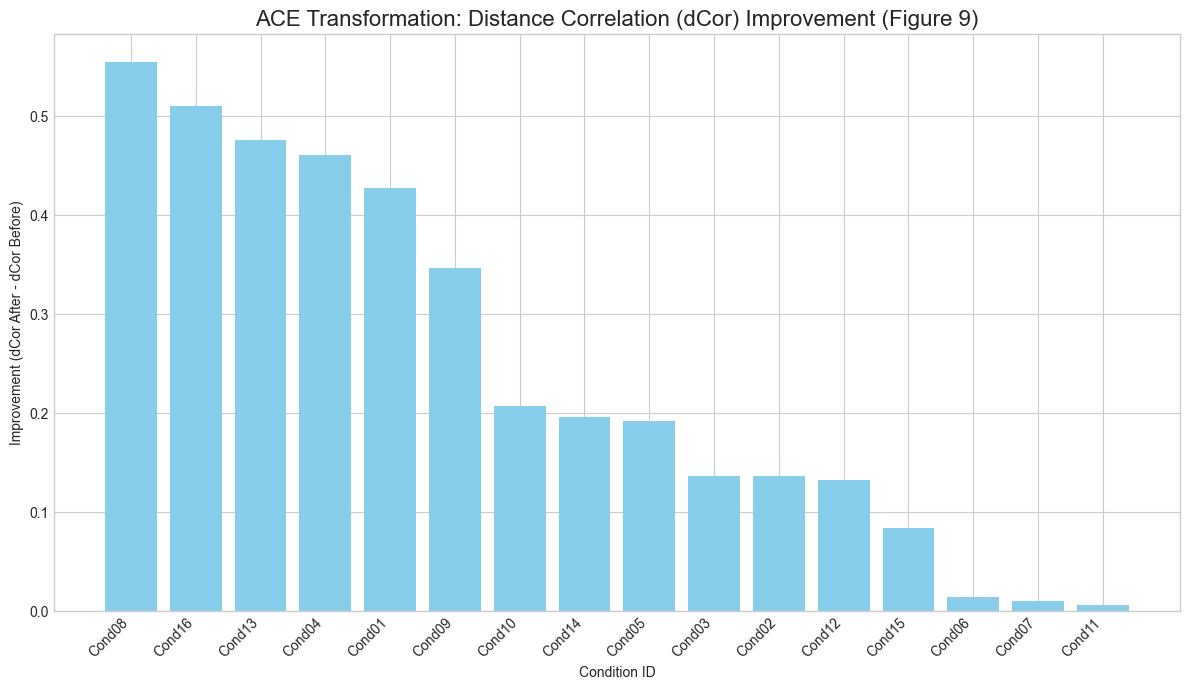

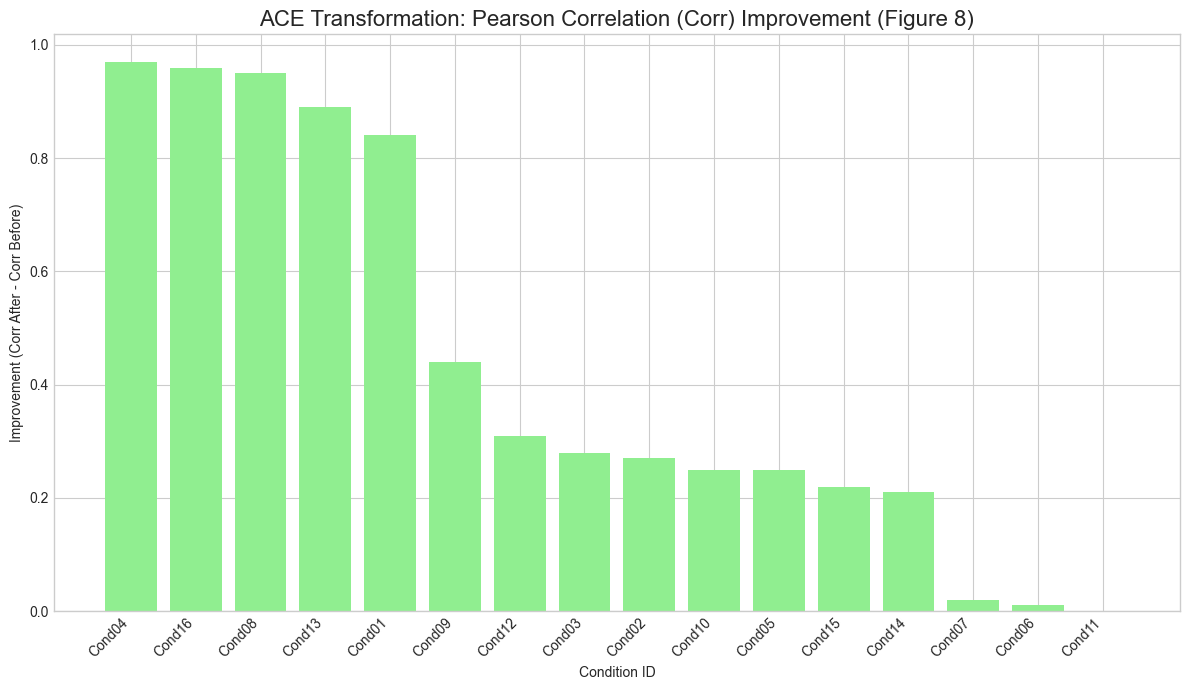

In [6]:
# This cell assumes 'results_df' was created in the previous cell.
# If you are running this cell independently, you must run the previous cell first.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Define data directly as a Python list (fixes parsing error)
# This is a fallback in case the previous cell (results_df) failed or was not run.
try:
    df = results_df.copy()
except NameError:
    print("Warning: 'results_df' not found from previous cell. Using static data for this cell.")
    data = [
        ['Cond1', 'y = x^2', 'normal(0, 1)', 'normal(0, 1)', 0.06, 0.39, 0.90, 0.82],
        ['Cond2', 'y = x^2', 'uniform(-1, 1)', 'normal(0, 1)', 0.02, 0.14, 0.29, 0.27],
        ['Cond3', 'y = -x^2', 'uniform(-1, 1)', 'normal(0, 1)', 0.02, 0.14, 0.30, 0.28],
        ['Cond4', 'y = -x^2', 'normal(0, 1)', 'uniform(0, 1)', 0.02, 0.52, 0.99, 0.98],
        ['Cond5', 'y = x^3', 'normal(0, 1)', 'normal(0, 1)', 0.71, 0.74, 0.96, 0.93],
        ['Cond6', 'y = x^3', 'uniform(-1, 1)', 'normal(0, 1)', 0.32, 0.28, 0.33, 0.29],
        ['Cond7', 'y = -x^3', 'uniform(-1, 1)', 'normal(0, 1)', 0.34, 0.30, 0.36, 0.31],
        ['Cond8', 'y = x^4', 'normal(0, 1)', 'normal(0, 1)', 0.04, 0.43, 0.99, 0.99],
        ['Cond9', 'y = x^5', 'normal(0, 1)', 'normal(0, 1)', 0.53, 0.64, 0.97, 0.99],
        ['Cond10', 'y = e^x', 'normal(0, 1)', 'normal(0, 1)', 0.71, 0.71, 0.96, 0.92],
        ['Cond11', 'y = e^x', 'uniform(0, 1)', 'normal(0, 1)', 0.44, 0.40, 0.44, 0.41],
        ['Cond12', 'y = ln(|x|+1)', 'normal(0, 1)', 'normal(0, 1)', 0.01, 0.17, 0.32, 0.30],
        ['Cond13', 'y = x^2', 'normal(0, 1)', 'uniform(-1, 1)', 0.07, 0.46, 0.96, 0.93],
        ['Cond14', 'y = x^3', 'normal(0, 1)', 'uniform(-1, 1)', 0.78, 0.79, 0.99, 0.98],
        ['Cond15', 'y = e^x', 'normal(0, 1)', 'uniform(0, 1)', 0.76, 0.89, 0.98, 0.98],
        ['Cond16', 'y = x^2 + U(0, 0.1)', 'uniform(-1, 1)', 'uniform(0, 0.1)', 0.04, 0.48, 1.00, 0.99]
    ]
    columns = ['ID', 'Function', 'X Dist.', 'Err Dist.', 'Corr Before', 'dCor Before', 'Corr After', 'dCor After']
    df = pd.DataFrame(data, columns=columns)

# 2. Calculate improvement
df['Corr Improvement'] = df['Corr After'] - df['Corr Before']
df['dCor Improvement'] = df['dCor After'] - df['dCor Before']

# 3. Calculate improvement ranks
df['Corr Rank'] = df['Corr Improvement'].rank(method='min', ascending=False).astype(int)
df['dCor Rank'] = df['dCor Improvement'].rank(method='min', ascending=False).astype(int)

# 4. Sort by dCor improvement and display table (Table 3)
results_table = df.sort_values('dCor Rank')

print("ACE Transformation Improvement Results (sorted by dCor Rank)")
display(results_table[['ID', 'Function', 'dCor Before', 'dCor After', 'dCor Improvement', 'dCor Rank']])


# --- 5. Generate Graphs ---

# dCor Improvement Graph (Figure 9)
df_sorted_dcor = df.sort_values('dCor Improvement', ascending=False)
plt.style.use('seaborn-v0_8-whitegrid')
fig1, ax1 = plt.subplots(figsize=(12, 7))
ax1.bar(df_sorted_dcor['ID'], df_sorted_dcor['dCor Improvement'], color='skyblue')
ax1.set_title('ACE Transformation: Distance Correlation (dCor) Improvement (Figure 9)', fontsize=16)
ax1.set_ylabel('Improvement (dCor After - dCor Before)')
ax1.set_xlabel('Condition ID')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{output_dir}/dcor_improvement_rank.png") # Save to output directory
plt.show()


# Corr Improvement Graph (Figure 8)
df_sorted_corr = df.sort_values('Corr Improvement', ascending=False)
fig2, ax2 = plt.subplots(figsize=(12, 7))
ax2.bar(df_sorted_corr['ID'], df_sorted_corr['Corr Improvement'], color='lightgreen')
ax2.set_title('ACE Transformation: Pearson Correlation (Corr) Improvement (Figure 8)', fontsize=16)
ax2.set_ylabel('Improvement (Corr After - Corr Before)')
ax2.set_xlabel('Condition ID')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{output_dir}/corr_improvement_rank.png") # Save to output directory
plt.show()

Figure 10: Scatter plots and correlation changes for solar power data (Time vs. Irradiance) before and after ACE transformation \
Table 4: Summary of solar power data analysis results

Loading local file 'Plant_1_Weather_Sensor_Data.csv'...
Data load and preprocessing complete.

Starting 24-hour cycle analysis of all solar data (Hour_of_Day vs IRRADIATION)...

Generating and saving 'Before' and 'After' analysis graphs to files.


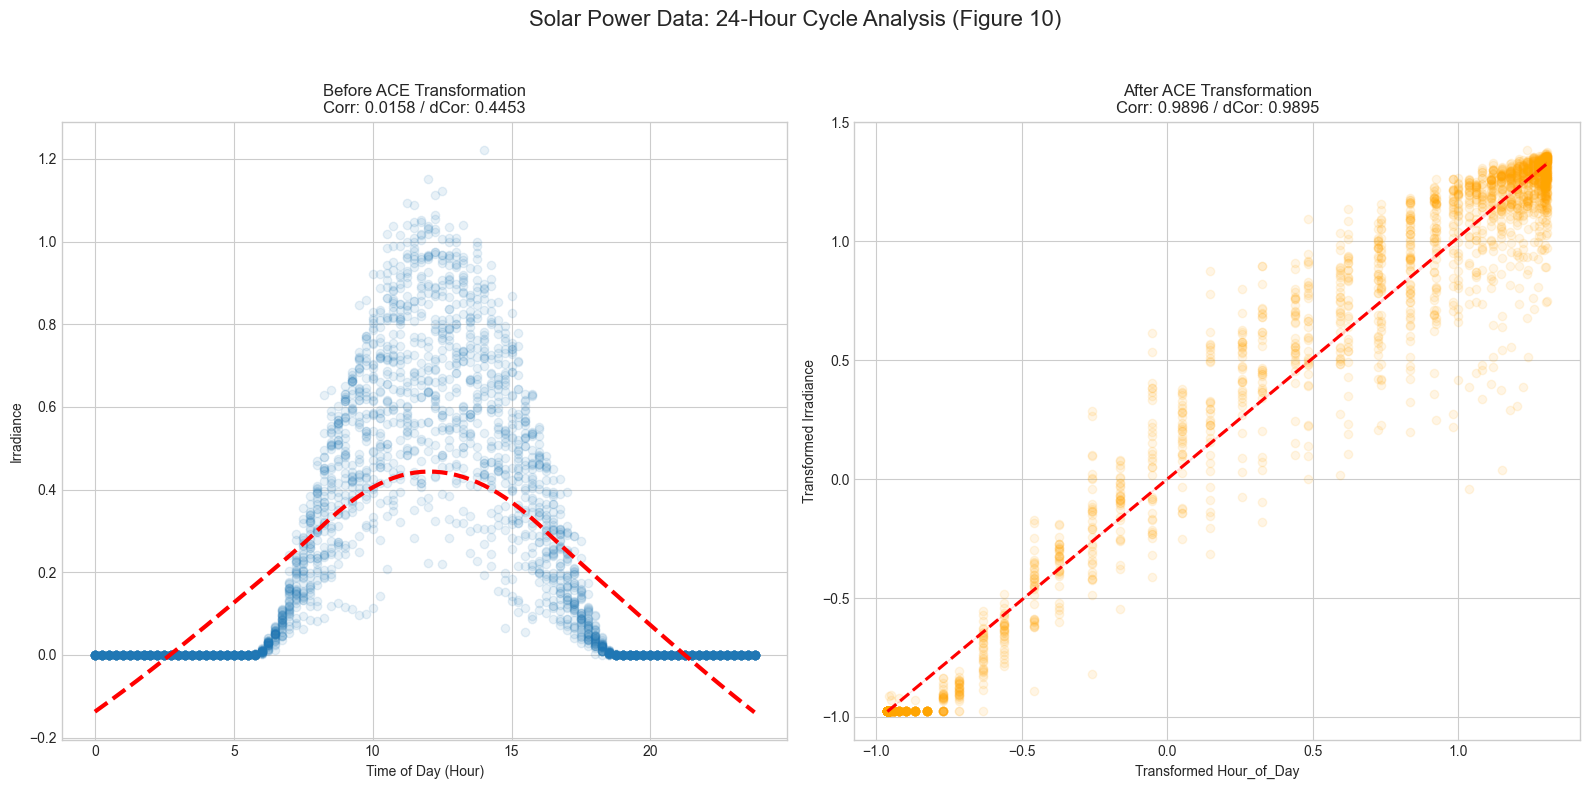

Combined graph saved successfully: 'ace_simulations_combined/solar_cycle_combined.png'

Solar Irradiance (24-Hour Cycle over All Days) Analysis Results (Table 4)


,Corr Before,dCor Before,Corr After (ACE),dCor After (ACE),Delta dCor
0,0.0158,0.4453,0.9896,0.9895,0.5442


In [7]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- Step 1: R Environment Setup (already completed) ---

# --- Step 2: Import rpy2 libraries (already completed) ---
# print("R libraries (acepack, energy) are already loaded.")
# ---

# --- 3. Solar Power Data Load Function (using all data) ---
def load_local_solar_data():
    """Loads the locally downloaded Kaggle solar sensor data and preprocesses it into a 24-hour cycle."""
    filename = 'Plant_1_Weather_Sensor_Data.csv'
    print(f"Loading local file '{filename}'...")
    try:
        df = pd.read_csv(filename)
        
        # --- Modified section: Use all data ---
        # Convert 'DATE_TIME' column to datetime objects
        df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
        
        # Create the 'Hour_of_Day' variable (X-axis) for all data
        df['Hour_of_Day'] = df['DATE_TIME'].dt.hour + df['DATE_TIME'].dt.minute / 60
        
        # Remove unnecessary rows
        df.dropna(subset=['Hour_of_Day', 'IRRADIATION'], inplace=True)
        
        print("Data load and preprocessing complete.\n")
        return df
    except FileNotFoundError:
        print(f"Error: '{filename}' file not found.")
        return None
    except Exception as e:
        print(f"Error during data load: {e}")
        return None

# --- 4. Run Analysis and Visualization ---
results_list_solar = []
df_analysis = load_local_solar_data()

if df_analysis is not None and not df_analysis.empty:
    # Apply sampling again as the dataset is large
    sample_size = 5000
    if len(df_analysis) > sample_size:
        print(f"Sampling {sample_size} from total {len(df_analysis)} data points for analysis.\n")
        df_sampled = df_analysis.sample(n=sample_size, random_state=42)
    else:
        df_sampled = df_analysis

    x_col = 'Hour_of_Day'
    y_col = 'IRRADIATION'
    
    x_samples = df_sampled[x_col].values
    y_samples = df_sampled[y_col].values
    
    print(f"Starting 24-hour cycle analysis of all solar data ({x_col} vs {y_col})...\n")
    
    with localconverter(ro.default_converter + numpy2ri.converter):
        r_x = ro.FloatVector(x_samples)
        r_y = ro.FloatVector(y_samples)
        
        corr_before = round(np.corrcoef(x_samples, y_samples)[0, 1], 4)
        dcor_before = round(energy.dcor(r_x, r_y)[0], 4)

        ace_results_r = acepack.ace(r_x, r_y)
        ace_names = list(ace_results_r.names())
        transformed_x_ace = np.array(ace_results_r[ace_names.index('tx')])
        transformed_y_ace = np.array(ace_results_r[ace_names.index('ty')])
        
        corr_ace = round(np.corrcoef(transformed_x_ace.flatten(), transformed_y_ace.flatten())[0, 1], 4)
        dcor_ace = round(energy.dcor(ro.FloatVector(transformed_x_ace.flatten()), ro.FloatVector(transformed_y_ace.flatten()))[0], 4)

        # --- 4. Save Data for Table 6 (Table 4 in notebook) ---
        result_row = {
            'ID': 'Solar Irradiance (All Days)',
            'Description': f'24-Hour Cycle ({x_col} vs {y_col})',
            'Corr Before': corr_before,
            'dCor Before': dcor_before,
            'Corr After (ACE)': corr_ace,
            'dCor After (ACE)': dcor_ace,
            'Delta dCor': round(dcor_ace - dcor_before, 4) # Add improvement metric
        }
        results_list_solar.append(result_row)

        # --- 5. Visualization for Figure 8 (Fig 10 in notebook) ---
        print("Generating and saving 'Before' and 'After' analysis graphs to files.")
        
        # Create a 1x2 subplot figure
        fig_solar, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(16, 8))
        fig_solar.suptitle('Solar Power Data: 24-Hour Cycle Analysis (Figure 10)', fontsize=16)

        # Before Plot
        sns.regplot(data=df_sampled, x=x_col, y=y_col, lowess=True,
                    line_kws={'color': 'red', 'linewidth': 3, 'linestyle': '--'},
                    scatter_kws={'alpha': 0.1}, ax=ax_before)
        ax_before.set_title(f'Before ACE Transformation\nCorr: {corr_before} / dCor: {dcor_before}')
        ax_before.set_xlabel('Time of Day (Hour)')
        ax_before.set_ylabel('Irradiance')

        # After Plot
        sns.regplot(x=transformed_x_ace, y=transformed_y_ace, 
                    line_kws={'color': 'red', 'linestyle': '--'}, 
                    scatter_kws={'alpha': 0.1, 'color': 'orange'}, ax=ax_after)
        ax_after.set_title(f'After ACE Transformation\nCorr: {corr_ace} / dCor: {dcor_ace}')
        ax_after.set_xlabel('Transformed Hour_of_Day')
        ax_after.set_ylabel('Transformed Irradiance')
        
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        # Save the combined figure
        plt.savefig(f"{output_dir}/solar_cycle_combined.png")
        plt.show()
        print(f"Combined graph saved successfully: '{output_dir}/solar_cycle_combined.png'")


# --- 6. Display Table 6 (Table 4 in notebook) --- 
if results_list_solar:
    results_df_solar = pd.DataFrame(results_list_solar)
    print("\n" + "="*95)
    print("Solar Irradiance (24-Hour Cycle over All Days) Analysis Results (Table 4)")
    print("="*95)
    # Display only the columns relevant to the paper's Table 4
    display(results_df_solar[['Corr Before', 'dCor Before', 'Corr After (ACE)', 'dCor After (ACE)', 'Delta dCor']].round(4))
else:
    print("\nAnalysis could not be performed.")